# Profile: retail, daily

The earlier examples each isolate one piece of the pipeline. The *putting-it-together* profiles
run the whole pipeline end to end for a concrete investor, so you can see how the choices
compose. This first profile is a **retail investor rebalancing daily** with a small account: the
constraints are compute, trading cost, and capital, not sophistication.

The reasoning, following the [strategy decision framework](../../user_guide/06_Choosing_a_Strategy.md):

  - **Compute is cheap but frequent** — rebalancing every day rules out heavy optimisations; a
    single convex solve is right.
  - **Trading is the enemy** — daily turnover compounds costs, so we cap turnover and charge fees
    explicitly, letting the optimiser trade only when it is worth it.
  - **The account is small** — discretisation matters, so finite allocation is not an afterthought.
  - **Robustness over edge** — a tight weight cap buys diversification and stability.

> **When to reach for this**
>
> This is the template for any cost- and capital-constrained, high-frequency book: keep the
> optimisation light, control turnover and fees at the optimiser, and finish with a finite
> allocation sized to the real account.

In [1]:
using PortfolioOptimisers, CSV, TimeSeries, DataFrames, PrettyTables, Clarabel, StatsPlots,
      GraphRecipes

resfmt = (v, i, j) -> begin
    return if j == 1
        v
    else
        isa(v, AbstractFloat) ? "$(round(v*100, digits=3)) %" : v
    end
end;

## 1. Data and current book

We use the S&P 500 slice, and assume the investor currently holds an equal-weight book — the
reference point turnover is measured against.

In [2]:
X = TimeArray(CSV.File(joinpath(@__DIR__, "..", "SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X)
pr = prior(EmpiricalPrior(), rd)
N = length(rd.nx)

prices = vec(values(X)[end, :])
current_book = fill(1 / N, N)

slv = Solver(; name = :clarabel, solver = Clarabel.Optimizer,
             settings = Dict("verbose" => false),
             check_sol = (; allow_local = true, allow_almost = true))

Solver
         name ┼ Symbol: :clarabel
       solver ┼ UnionAll: Clarabel.MOIwrapper.Optimizer
     settings ┼ Dict{String, Bool}: Dict{String, Bool}("verbose" => 0)
    check_sol ┼ @NamedTuple{allow_local::Bool, allow_almost::Bool}: (allow_local = true, allow_almost = true)
  add_bridges ┴ Bool: true


## 2. The optimisation

One light convex solve: minimum risk, a 15% per-name cap for diversification, a daily turnover
budget against the current book, and explicit fees so trades must justify their cost.

In [3]:
retail = optimise(MeanRisk(; obj = MinimumRisk(),
                           opt = JuMPOptimiser(; pe = pr, slv = slv,
                                               wb = WeightBounds(; lb = 0.0, ub = 0.15),
                                               tn = Turnover(; w = current_book,
                                                             val = 0.05),
                                               fees = Fees(; l = 0.001))))

pretty_table(DataFrame("Asset" => rd.nx, "Current" => current_book, "Target" => retail.w);
             formatters = [resfmt],
             title = "Retail daily target — capped, low-turnover, net of fees")

Retail daily target — capped, low-turnover, net of fees
┌────────┬─────────┬─────────┐
│  Asset │ Current │  Target │
│ String │ Float64 │ Float64 │
├────────┼─────────┼─────────┤
│   AAPL │   5.0 % │   0.0 % │
│    AMD │   5.0 % │   0.0 % │
│    BAC │   5.0 % │   0.0 % │
│    BBY │   5.0 % │   0.0 % │
│    CVX │   5.0 % │  10.0 % │
│     GE │   5.0 % │ 0.246 % │
│     HD │   5.0 % │ 0.721 % │
│    JNJ │   5.0 % │  10.0 % │
│    JPM │   5.0 % │ 4.818 % │
│     KO │   5.0 % │  10.0 % │
│    LLY │   5.0 % │ 4.804 % │
│    MRK │   5.0 % │  10.0 % │
│   MSFT │   5.0 % │   0.0 % │
│    PEP │   5.0 % │  10.0 % │
│      ⋮ │       ⋮ │       ⋮ │
└────────┴─────────┴─────────┘
                6 rows omitted


The cap and turnover budget keep the book diversified and close to where it started, so the daily
rebalance is small and cheap.

## 3. Finite allocation

The account is \$10,000. `GreedyAllocation` converts the target into whole shares — no MIP
solver, instant, which suits a daily cadence.

In [4]:
alloc = optimise(GreedyAllocation(), retail.w, prices, 10_000.0)

invested = sum(alloc.shares .* prices)
pretty_table(DataFrame("Asset" => rd.nx, "Target" => retail.w,
                       "Shares" => round.(Int, alloc.shares), "Realised" => alloc.w);
             formatters = [resfmt],
             title = "\$10,000 allocated — invested \$$(round(Int, invested)), cash left \$$(round(alloc.cash, digits = 2))")

$10,000 allocated — invested $9997, cash left $2.99
┌────────┬─────────┬────────┬──────────┐
│  Asset │  Target │ Shares │ Realised │
│ String │ Float64 │  Int64 │  Float64 │
├────────┼─────────┼────────┼──────────┤
│   AAPL │   0.0 % │      0 │    0.0 % │
│    AMD │   0.0 % │      0 │    0.0 % │
│    BAC │   0.0 % │      0 │    0.0 % │
│    BBY │   0.0 % │      0 │    0.0 % │
│    CVX │  10.0 % │      6 │ 10.427 % │
│     GE │ 0.246 % │      0 │    0.0 % │
│     HD │ 0.721 % │      0 │    0.0 % │
│    JNJ │  10.0 % │      5 │  8.707 % │
│    JPM │ 4.818 % │      3 │  3.888 % │
│     KO │  10.0 % │     15 │  9.394 % │
│    LLY │ 4.804 % │      2 │  7.264 % │
│    MRK │  10.0 % │      9 │  9.865 % │
│   MSFT │   0.0 % │      0 │    0.0 % │
│    PEP │  10.0 % │      5 │  8.967 % │
│      ⋮ │       ⋮ │      ⋮ │        ⋮ │
└────────┴─────────┴────────┴──────────┘
                          6 rows omitted


## 4. The book

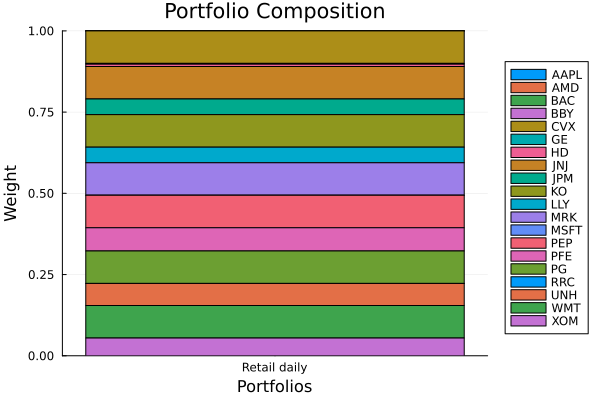

In [5]:
plot_stacked_bar_composition([retail], rd; xticks = (1:1, ["Retail daily"]))

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*